## Load Necessary Modules

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

## Load the Model

In [2]:
pretrained_model = tf.keras.applications.MobileNetV2(include_top=True, weights='imagenet')
pretrained_model.trainable = False

decode_predictions = tf.keras.applications.mobilenet_v2.decode_predictions

## Preprocessing and labeling helpers

In [3]:
def preprocess(image):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    image = image[None, ...]
    return image

def get_imagenet_label(probs):
    return decode_predictions(probs, top=1)[0][0]

## Load image and Predict without Adversarial Attack

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


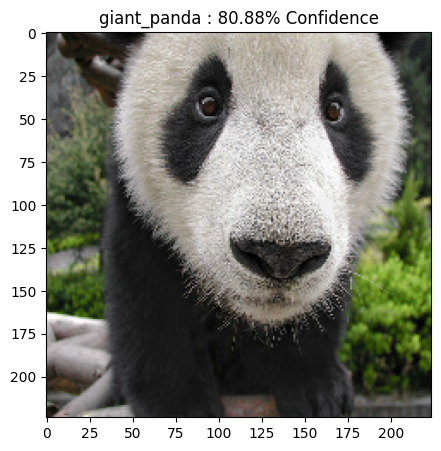

In [4]:

image_path = tf.keras.utils.get_file(
    'panda.jpeg',
    'https://sdzwildlifeexplorers.org/sites/default/files/2017-07/pandas-closeup.jpg',
)

image_raw = tf.io.read_file(image_path)
image = tf.image.decode_image(image_raw)
image = preprocess(image)

# Predict original class
image_probs = pretrained_model.predict(image)
plt.figure(figsize=(5,5))
plt.imshow(image[0] * 0.5 + 0.5)
_, image_class, class_confidence = get_imagenet_label(image_probs)
plt.title(f"{image_class} : {class_confidence*100:.2f}% Confidence")
plt.show()

## Fast Gradient Signed Method (FGSM)

In [5]:

loss_object = tf.keras.losses.CategoricalCrossentropy()

def create_adversarial_pattern(input_image, input_label):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = pretrained_model(input_image)
        loss = loss_object(input_label, prediction)
    gradient = tape.gradient(loss, input_image)
    signed_grad = tf.sign(gradient)
    return signed_grad

## Adding Noise and Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


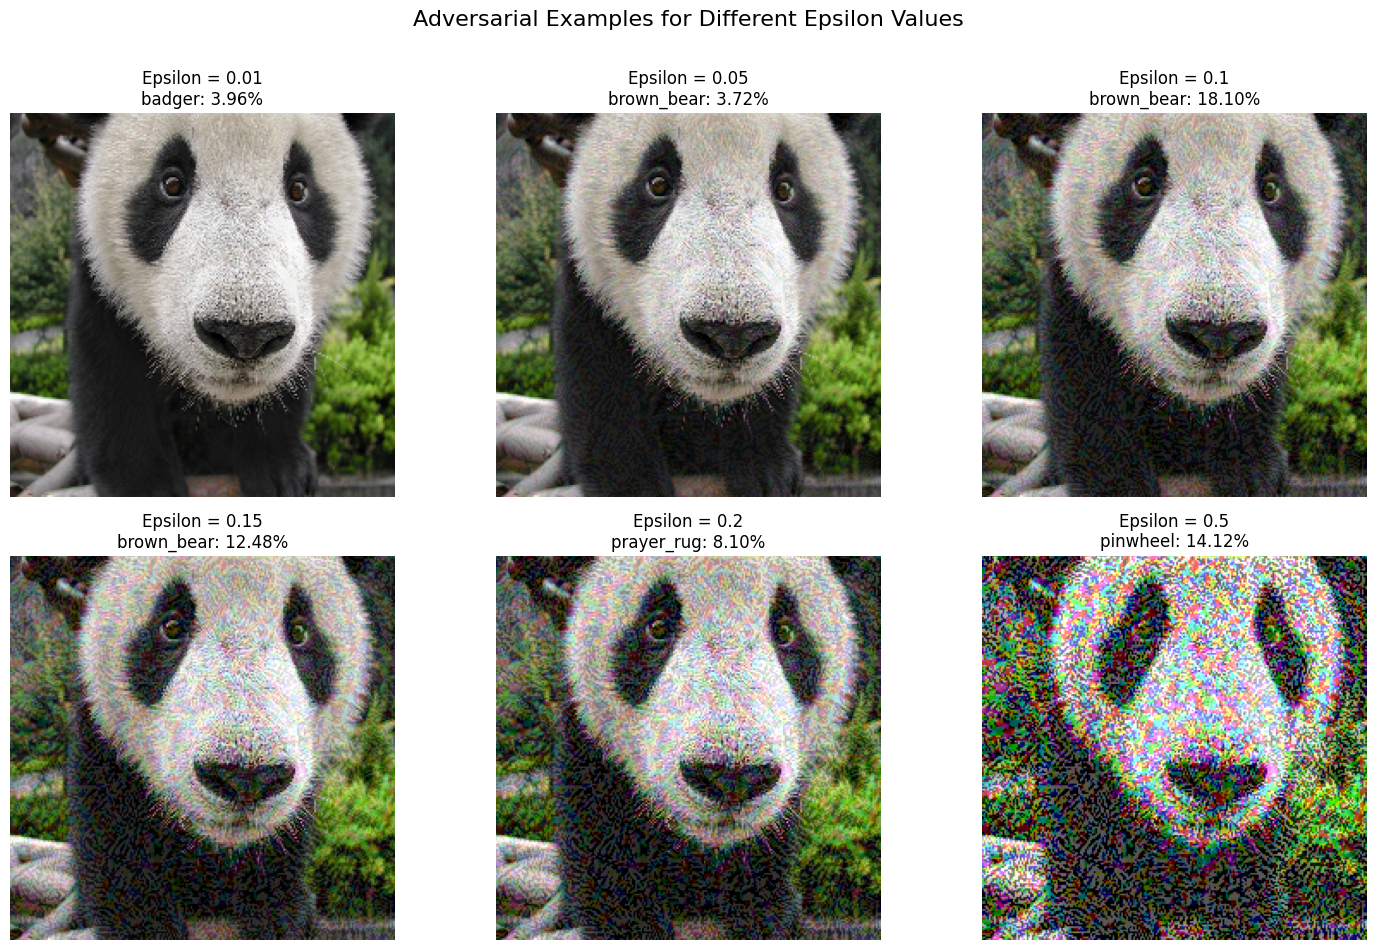

In [6]:

label = tf.one_hot(np.argmax(image_probs), 1000)
label = tf.reshape(label, (1, 1000))
perturbations = create_adversarial_pattern(image, label)

epsilons = [0.01, 0.05, 0.1, 0.15, 0.2, 0.5]

plt.figure(figsize=(15, 9))

for i, eps in enumerate(epsilons):
    adv_image = image + eps * perturbations
    adv_image = tf.clip_by_value(adv_image, -1, 1)

    # Predict
    adv_probs = pretrained_model.predict(adv_image)
    _, adv_class, adv_conf = get_imagenet_label(adv_probs)

    # Plot
    plt.subplot(2, len(epsilons)//2, i+1)
    plt.imshow(adv_image[0] * 0.5 + 0.5)
    plt.title(f"Epsilon = {eps}\n{adv_class}: {adv_conf*100:.2f}%")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Adversarial Examples for Different Epsilon Values", fontsize=16, y=1.05)
plt.show()

## Adversarial Attack with Gaussian noise

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


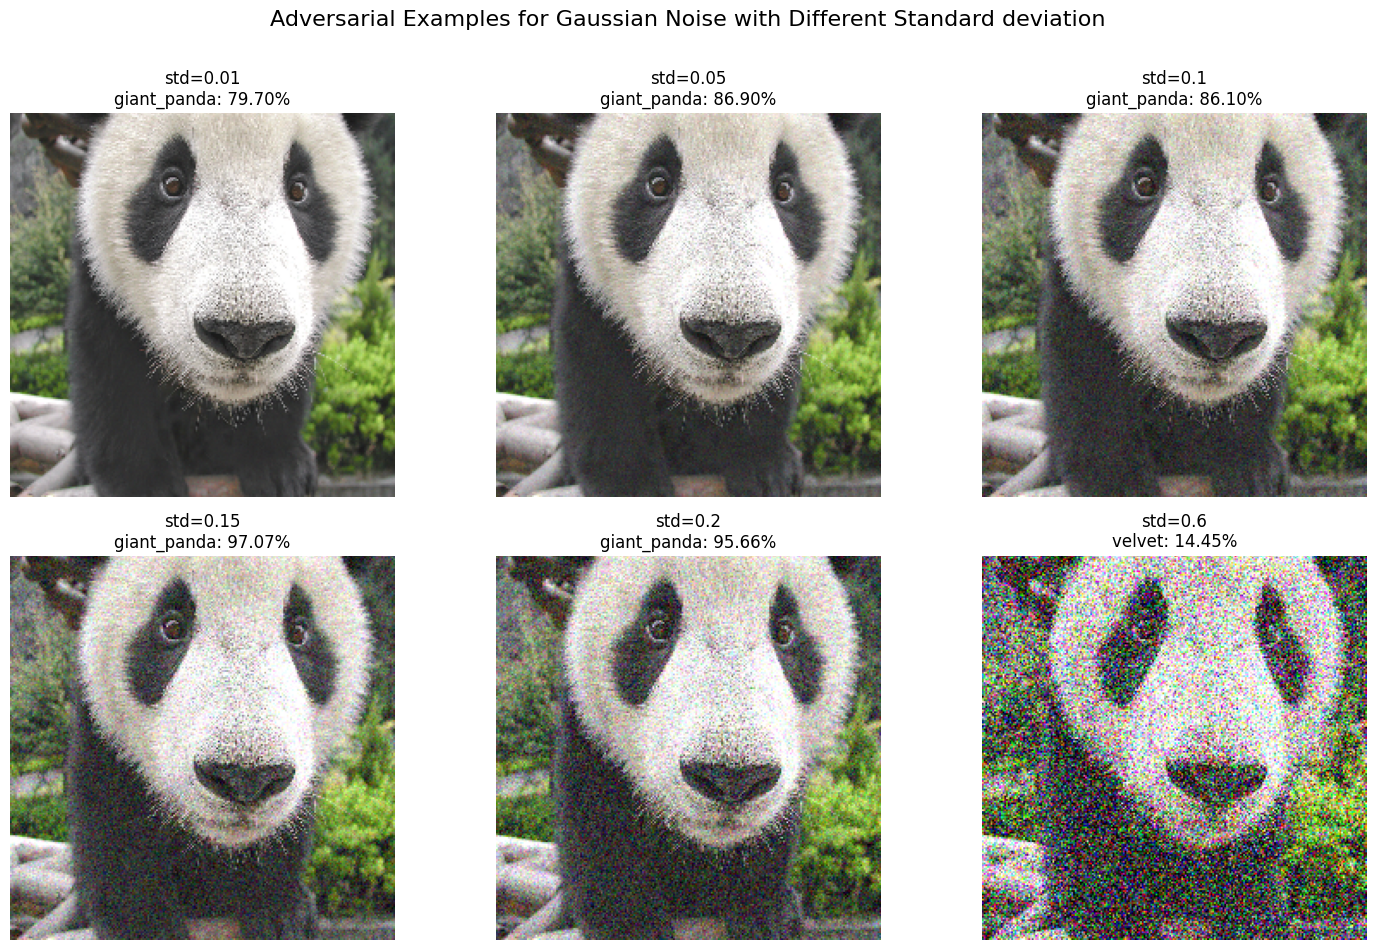

In [7]:

stddev = [0.01, 0.05, 0.1, 0.15, 0.2, 0.6]

plt.figure(figsize=(15, 9))

for i, std in enumerate(stddev):
    gaussian_noise = tf.random.normal(shape=image.shape, mean=0.2, stddev=std)
    noisy_image = tf.clip_by_value(image + gaussian_noise, -1.0, 1.0)
    # Apply FGSM with current epsilon
    adv_image = noisy_image
    adv_image = tf.clip_by_value(adv_image, -1, 1)

    # Predict
    adv_probs = pretrained_model.predict(adv_image)
    _, adv_class, adv_conf = get_imagenet_label(adv_probs)

    # Plot
    plt.subplot(2, len(stddev)//2, i+1)
    plt.imshow(adv_image[0] * 0.5 + 0.5)
    plt.title(f"std={std}\n{adv_class}: {adv_conf*100:.2f}%")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Adversarial Examples for Gaussian Noise with Different Standard deviation", fontsize=16, y=1.05)
plt.show()



